# Detección de Inyecciones SQL mediante técnicas de procesamiento de lenguaje natural y aprendizaje automático

## Introducción
Por Gonzalo Benito, Lic. en Sistemas de Información, Universidad Nacional de Luján, Argentina.

Este trabajo propone desarrollar un sistema de detección de ataques de Inyección SQL utilizando técnicas de procesamiento de lenguaje natural (NLP) y algoritmos de machine learning. Se empleó un dataset obtenido de Kaggle que contiene sentencias SQL etiquetadas como peligrosas o benignas. La metodología incluyó la transformación de las sentencias en vectores mediante **embeddings semánticos** utilizando modelos pre-entrenados, seguida de la aplicación de **PCA** para reducir dimensionalidad y algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo fue evaluar y comparar el desempeño de los modelos mediante métricas de precisión, recall y F1-score, y **demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning**.

#### Detalles de lo que se incluirá en este trabajo
La metodología seguirá un enfoque basado en **embeddings semánticos** generados por modelos de lenguaje pre-entrenados, específicamente usando 'all-MiniLM-L6-v2'. Con este método, cada sentencia se transforma en un vector denso de 384 dimensiones que captura el significado semántico de la consulta SQL. A diferencia de las representaciones basadas en frecuencia (como TF-IDF), los embeddings pueden detectar patrones maliciosos más sutiles y generalizar mejor a variantes de ataques no vistas anteriormente. Se aplicará **PCA** para reducir la dimensionalidad y visualizar los datos, seguido de la evaluación con algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo es evaluar y comparar el desempeño de las distintas configuraciones de los modelos, mediante las métricas de precisión más usadas, y demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning.

## Descripción del dataset
El dataset utilizado es 'SQL Injection Dataset' de Syed Saqlain Hussain (Kaggle), con 30.920 filas y dos columnas principales: `Sentence` (consulta SQL o texto) y `Label` (0=benigna, 1=inyección).

| Atributo | Tipo | Descripción |
| -------- | ---- | ----------- |
| Sentence | texto | Consulta SQL completa o texto |
| Label | categórica | 0 = no inyección, 1 = inyección SQL |

De la variable Sentence se obtendrá el conjunto de features durante la fase de Feature Engineering, utilizando **embeddings semánticos** con modelos pre-entrenados como 'all-MiniLM-L6-v2'.

Link del dataset: https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset

## Instalación de librerías necesarias

In [25]:
# Dependencias básicas
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install numpy==1.26.4
%pip install imbalanced-learn

# Librerías específicas para embeddings
%pip install sentence-transformers
%pip install torch  # Requerido por sentence-transformers

import pandas as pd
import gc  # Para gestión de memoria
import numpy as np

# Configuración para optimizar memoria
pd.options.mode.copy_on_write = True  # Evita copias innecesarias en pandas

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importación del dataset y selección de features

In [26]:
data: pd.DataFrame = pd.read_csv(
    "./data/SQLiV3.csv"
)  # El dataset debe tener columnas 'Sentence' y 'Label'
data

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [27]:
data = data[["Sentence", "Label"]].copy()  # Seleccionar solo las columnas necesarias
data["Sentence"] = data["Sentence"].astype(str)
data["length"] = data["Sentence"].apply(len)
data

,Sentence,Label,length
0,""" or pg_sleep ( __TIME__ ) --",1,33
1,create user name identified by pass123 tempora...,NaN,89
2,AND 1 = utl_inaddr.get_host_address ( ...,1,218
3,select * from users where id = '1' or @ @1 ...,1,90
4,"select * from users where id = 1 or 1#"" ( ...",1,85
...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,37
30915,DELETE FROM tomorrow,0,20
30916,SELECT wide ( s ) FROM west,0,28
30917,SELECT * FROM ( SELECT slide FROM breath ),0,44


## Preprocesamiento

### Limpieza de missing values y ruido

In [28]:
# Eliminar filas donde 'Sentence' es NaN
data = data.dropna(subset=["Sentence"])

# Me quedo solo con las clases 0 y 1 (por si hay algún otro valor en 'Label', como un string)
data = data[data["Label"].isin(["0", "1"])]

## Análisis exploratorio de datos (EDA)
Exploramos la distribución de clases y longitud de sentencias.

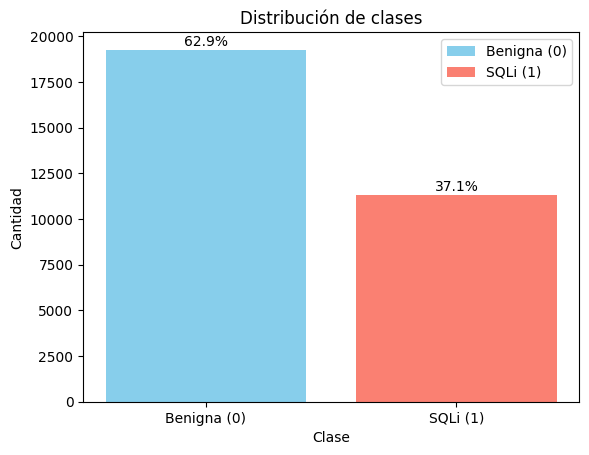

In [29]:
# Distribución de clases
import matplotlib.pyplot as plt

value_counts = data["Label"].value_counts()
percentage = (value_counts / value_counts.sum()) * 100
labels = ["Benigna (0)", "SQLi (1)"]

fig, axes = plt.subplots()
bars = axes.bar(labels, value_counts, color=["skyblue", "salmon"], label=labels)

# Texto de porcentaje arriba de cada barra
for bar, pct in zip(bars, percentage):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
    )

axes.set_title("Distribución de clases")
axes.set_xlabel("Clase")
axes.set_ylabel("Cantidad")
axes.legend()
plt.show()

Las clases están desbalanceadas. La clase mayoritaria es la 0 (sentencias benignas). Recurriremos a técnicas de balanceo para solucionar este problema.

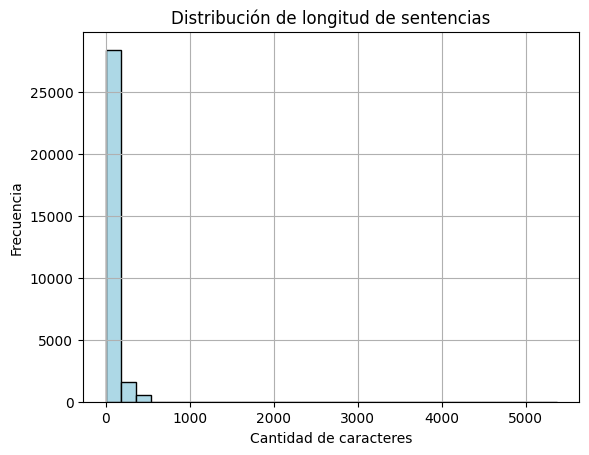

Cantidad de caracteres de la sentencia más larga: 5370


,Sentence,Label,length
19341,de]]> </email_address> <find_account_answer...,0,5370
19667,SELECT wp_posts.* FROM wp_posts LEFT JOIN wp_p...,0,559
19663,SELECT wp_posts.ID FROM wp_posts LEFT JOIN wp_...,0,529
9780,1'|| ( select 'rjis' from dual where 7696 =...,1,456
7270,"-6475"" ) ) ) or 4144 = ( selec...",1,455
...,...,...,...
628,!,1,1
19312,0,1,1
438,?,1,1
106,s,1,1


In [30]:
data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

print(f"Cantidad de caracteres de la sentencia más larga: {data['length'].max()}")
data_sort_by_length = data.sort_values(by="length", ascending=False)
data_sort_by_length

Vemos que la sentencia 19341 tiene una longitud atípica, 10 veces mayor que la segunda sentencia más larga. Esta es benigna. La eliminaremos del dataset por ser un outlier. Luego volvemos a mostrar el histograma de longitudes de sentencia.

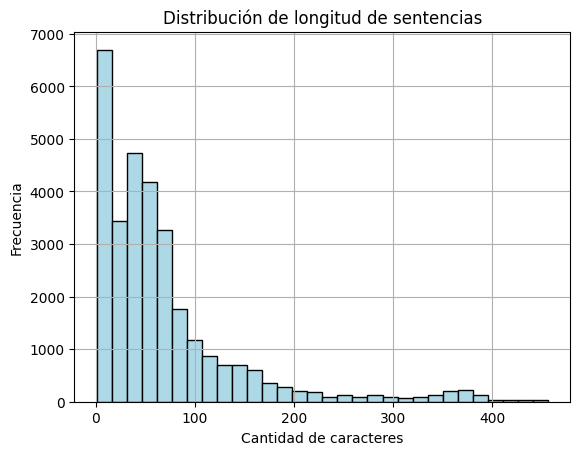

In [31]:
data = data[data["length"] <= 500]
data["length"].max()

data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

## Feature Engineering

Se exploran dos enfoques: TF-IDF (en otro notebook) y **embeddings semánticos** (este notebook). Los embeddings capturan el significado semántico de las sentencias SQL, mientras que TF-IDF se basa en frecuencias de n-gramas.

In [32]:
# Generación de embeddings usando sentence-transformers
from sentence_transformers import SentenceTransformer
import time

print("GENERACIÓN DE EMBEDDINGS CON SENTENCE-TRANSFORMERS:")
print("=" * 60)

# Cargar modelo pre-entrenado optimizado para tareas de clasificación
# all-MiniLM-L6-v2: 384 dimensiones
model_name = 'all-MiniLM-L6-v2'
print(f"Cargando modelo: {model_name}")
print("Fuente: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2")

embeddings_model = SentenceTransformer(model_name)

print("\n✓ Información del modelo:")
print(f"  Dimensiones del embedding: {embeddings_model.get_sentence_embedding_dimension()}")
print(f"  Modelo: {model_name}")
print("  Optimizado para: clasificación de texto y similitud semántica")

# Convertir sentencias a embeddings
print("\nGenerando embeddings para todas las sentencias...")
start_time = time.time()

# Usar batch processing para mayor eficiencia
sentences = data["Sentence"].tolist()
batch_size = 32  # Ajustar según memoria disponible

embeddings_matrix = embeddings_model.encode(
    sentences, 
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # Normalizar para mejor rendimiento en clasificación
)

end_time = time.time()

print("\n✓ Embeddings generados exitosamente:")
print(f"  Forma de la matriz: {embeddings_matrix.shape}")
print(f"  Tipo: {type(embeddings_matrix)}")
print(f"  Tiempo de procesamiento: {end_time - start_time:.2f} segundos")
print(f"  Memoria estimada: ~{embeddings_matrix.nbytes / 1024**2:.1f} MB")

# Verificar que no hay valores NaN
nan_count = np.isnan(embeddings_matrix).sum()
print(f"  Valores NaN: {nan_count}")

if nan_count > 0:
    print("⚠️ Detectados valores NaN, reemplazando con ceros...")
    embeddings_matrix = np.nan_to_num(embeddings_matrix, nan=0.0)

print("\n✓ OPTIMIZACIÓN: Embeddings normalizados y listos para PCA")

# Liberar modelo de memoria si es necesario
del embeddings_model
gc.collect()

GENERACIÓN DE EMBEDDINGS CON SENTENCE-TRANSFORMERS:
Cargando modelo: all-MiniLM-L6-v2
Fuente: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

✓ Información del modelo:
  Dimensiones del embedding: 384
  Modelo: all-MiniLM-L6-v2
  Optimizado para: clasificación de texto y similitud semántica

Generando embeddings para todas las sentencias...

✓ Información del modelo:
  Dimensiones del embedding: 384
  Modelo: all-MiniLM-L6-v2
  Optimizado para: clasificación de texto y similitud semántica

Generando embeddings para todas las sentencias...


Batches: 100%|██████████| 957/957 [01:19<00:00, 12.04it/s]




✓ Embeddings generados exitosamente:
  Forma de la matriz: (30606, 384)
  Tipo: <class 'numpy.ndarray'>
  Tiempo de procesamiento: 79.67 segundos
  Memoria estimada: ~44.8 MB
  Valores NaN: 0

✓ OPTIMIZACIÓN: Embeddings normalizados y listos para PCA


9929

In [33]:
# Usar matriz de embeddings como características
X_original = embeddings_matrix  # Matriz densa de embeddings
y_original = data["Label"].copy()

# Convertir etiquetas a tipo int8 para ahorrar memoria
y_original = y_original.astype("int8")

# Liberar variables innecesarias
del data["length"]  # No necesitamos más esta columna
del embeddings_matrix  # Ya está en X_original
gc.collect()

0

### t-SNE para Visualización y Reducción de Dimensionalidad

Aplicaremos t-SNE (t-Distributed Stochastic Neighbor Embedding) a los embeddings para:
1. **Reducir dimensionalidad**: De 384 a un número manejable de componentes  
2. **Visualización**: Excelente para análisis visual en 2D/3D
3. **Preservar estructura local**: Mantiene relaciones de proximidad semántica
4. **Detección de clusters**: Mejor separación visual de clases

**Ventajas de t-SNE con embeddings:**
- Los embeddings son densos (no sparse), ideal para t-SNE
- Preserva mejor la estructura local que PCA
- Excelente para visualización de datos de alta dimensionalidad
- Puede revelar clusters no lineales

**Fuentes:**
- [t-SNE for Data Visualization](https://scikit-learn.org/stable/modules/manifold.html#t-sne)
- [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/)

### Aplicación de t-SNE a embeddings

In [34]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import time

# Configuraciones de t-SNE para probar (basado en distill.pub/2016/misread-tsne/)
tsne_configs = [
    {"n_iter": 1000, "perplexity": 5, "name": "iter1000_perp5"},
    {"n_iter": 1000, "perplexity": 30, "name": "iter1000_perp30"},
    {"n_iter": 1000, "perplexity": 50, "name": "iter1000_perp50"},
    {"n_iter": 2000, "perplexity": 5, "name": "iter2000_perp5"},
    {"n_iter": 2000, "perplexity": 30, "name": "iter2000_perp30"},
    {"n_iter": 2000, "perplexity": 50, "name": "iter2000_perp50"},
]

PCA_INTERMEDIATE = 50  # Reducir primero a 50 con PCA, luego aplicar t-SNE

print("APLICANDO PCA + t-SNE CON MÚLTIPLES CONFIGURACIONES:")
print("=" * 60)

# Paso 1: PCA intermedio (siempre necesario para t-SNE con embeddings)
print(f"Paso 1: PCA {X_original.shape[1]} → {PCA_INTERMEDIATE} componentes...")
pca_intermediate = PCA(n_components=PCA_INTERMEDIATE, random_state=0)
X_pca_intermediate = pca_intermediate.fit_transform(X_original)
print(f"✓ Varianza explicada: {pca_intermediate.explained_variance_ratio_.sum():.3f}")

# Paso 2: Probar múltiples configuraciones de t-SNE
tsne_results = {}

for config in tsne_configs:
    print(f"\nPaso 2: t-SNE {config['name']} - {PCA_INTERMEDIATE} → 2 componentes...")
    
    start_time = time.time()
    tsne = TSNE(
        n_components=2, 
        random_state=0,
        perplexity=config["perplexity"],
        n_iter=config["n_iter"],
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_intermediate)
    end_time = time.time()
    
    tsne_results[config["name"]] = {
        "X_tsne": X_tsne,
        "tsne_obj": tsne,
        "time": end_time - start_time,
        "config": config
    }
    
    print(f"✓ {config['name']}: {end_time - start_time:.1f}s")

# Seleccionar configuración por defecto para el pipeline principal
default_config = "iter1000_perp30"  # Configuración estándar
X_processed = tsne_results[default_config]["X_tsne"]

preprocessing_objects = {
    "pca_intermediate": pca_intermediate,
    "tsne_results": tsne_results,
    "default_tsne": default_config,
    "method": "PCA + t-SNE (múltiples configuraciones)",
    "X_pca_intermediate": X_pca_intermediate
}

# Liberar memoria
del X_original
gc.collect()

APLICANDO PCA + t-SNE CON MÚLTIPLES CONFIGURACIONES:
Paso 1: PCA 384 → 50 componentes...
✓ Varianza explicada: 0.609

Paso 2: t-SNE iter1000_perp5 - 50 → 2 componentes...


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ iter1000_perp5: 41.3s

Paso 2: t-SNE iter1000_perp30 - 50 → 2 componentes...


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ iter1000_perp30: 48.5s

Paso 2: t-SNE iter1000_perp50 - 50 → 2 componentes...


...

/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ iter2000_perp30: 93.6s

Paso 2: t-SNE iter2000_perp50 - 50 → 2 componentes...


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ iter2000_perp50: 114.2s


0

### Visualización de componentes con t-SNE

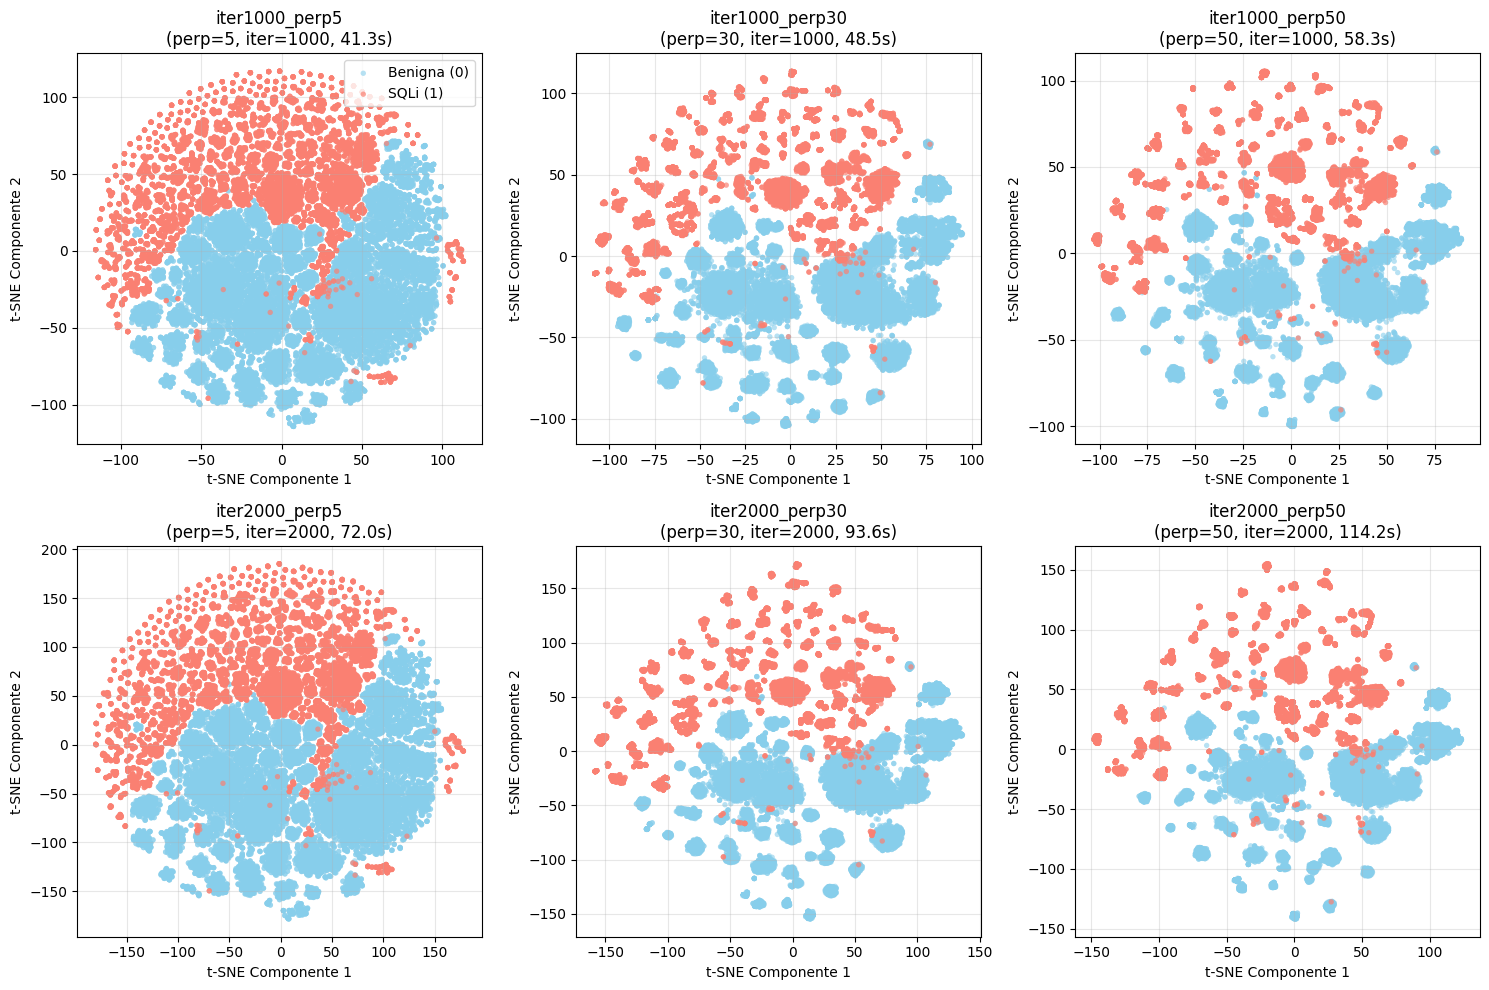


RESUMEN DE CONFIGURACIONES t-SNE:
iter1000_perp5: perplexity=5, iter=1000, tiempo=41.3s
iter1000_perp30: perplexity=30, iter=1000, tiempo=48.5s
iter1000_perp50: perplexity=50, iter=1000, tiempo=58.3s
iter2000_perp5: perplexity=5, iter=2000, tiempo=72.0s
iter2000_perp30: perplexity=30, iter=2000, tiempo=93.6s
iter2000_perp50: perplexity=50, iter=2000, tiempo=114.2s


In [35]:
# Visualización de todas las configuraciones de t-SNE
import matplotlib.pyplot as plt
import numpy as np

# Crear grid de subplots para todas las configuraciones
n_configs = len(tsne_results)
cols = 3
rows = (n_configs + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)

# Preparar datos para visualización
y_labels = y_original.values
mask_benign = y_labels == 0
mask_sqli = y_labels == 1

for idx, (config_name, result) in enumerate(tsne_results.items()):
    row = idx // cols
    col = idx % cols
    ax = axes[row, col]
    
    X_tsne_data = result["X_tsne"]
    component1 = X_tsne_data[:, 0]
    component2 = X_tsne_data[:, 1]
    
    # Scatter plot de componentes t-SNE
    ax.scatter(component1[mask_benign], component2[mask_benign], 
               c='skyblue', alpha=0.6, s=15, label='Benigna (0)', edgecolors='none')
    ax.scatter(component1[mask_sqli], component2[mask_sqli], 
               c='salmon', alpha=0.7, s=15, label='SQLi (1)', edgecolors='none')
    
    ax.set_xlabel('t-SNE Componente 1')
    ax.set_ylabel('t-SNE Componente 2')
    
    # Título con configuración y tiempo
    config_info = result["config"]
    time_info = result["time"]
    ax.set_title(f'{config_info["name"]}\n(perp={config_info["perplexity"]}, iter={config_info["n_iter"]}, {time_info:.1f}s)')
    
    if idx == 0:  # Solo mostrar leyenda en el primer gráfico
        ax.legend()
    ax.grid(True, alpha=0.3)

# Ocultar subplots vacíos
for idx in range(n_configs, rows * cols):
    row = idx // cols
    col = idx % cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

# Resumen de configuraciones
print("\nRESUMEN DE CONFIGURACIONES t-SNE:")
for config_name, result in tsne_results.items():
    config = result["config"]
    print(f"{config_name}: perplexity={config['perplexity']}, iter={config['n_iter']}, tiempo={result['time']:.1f}s")

### ~~Interpretación del resultado de PCA~~

~~El resultado obtenido muestra que los primeros 100 componentes principales explican únicamente el **9% de la varianza total** de los datos. Esto es sorprendentemente bajo y significa que:~~

~~1. **PCA no es efectivo** para este tipo de datos (matrices TF-IDF dispersas)~~
~~2. Se está perdiendo el **91% de la información** original~~
~~3. Los datos originales tienen una dimensionalidad muy alta y están muy dispersos~~

~~A pesar de esta limitación, continuamos con el análisis para evaluar si los modelos pueden aprender patrones útiles incluso con esta reducción drástica de información. En un escenario real, se recomendaría explorar alternativas como TruncatedSVD o trabajar directamente con la matriz TF-IDF original si los recursos computacionales lo permiten.~~

## División de Datos y Balanceo

Una vez aplicadas las transformaciones necesarias (TF-IDF y opcionalmente PCA), procedemos con la división estratificada de los datos y el balanceo del conjunto de entrenamiento.

**Metodología correcta:**
1. **División estratificada**: Primero dividir los datos originales en train (80%) y test (20%)
2. **Balanceo solo del training**: Aplicar SMOTE únicamente al conjunto de entrenamiento
3. **Preservar la realidad**: El conjunto de test mantiene la distribución original

In [36]:
from sklearn.model_selection import train_test_split

print("DIVISIÓN Y BALANCEADO DE DATOS CON t-SNE:")
print("=" * 40)

# Usar X_processed (datos de t-SNE - 2 componentes)
X_data = X_processed
y_data = y_original.astype("int8")

print(f"Datos para ML: {X_data.shape} (filas, componentes t-SNE)")

# División estratificada en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

print(f"División: train {X_train.shape}, test {X_test.shape}")
print(f"Distribución original: Benigna={np.bincount(y_data)[0]}, SQLi={np.bincount(y_data)[1]}")

DIVISIÓN Y BALANCEADO DE DATOS CON t-SNE:
Datos para ML: (30606, 2) (filas, componentes t-SNE)
División: train (24484, 2), test (6122, 2)
Distribución original: Benigna=19265, SQLi=11341


### Balanceo de Clases

Como observamos anteriormente, el dataset presenta un desbalance significativo entre las clases. Para mejorar el rendimiento de los modelos y evitar sesgos hacia la clase mayoritaria, aplicaremos la técnica SMOTE (Synthetic Minority Oversampling Technique), que genera muestras sintéticas de la clase minoritaria creando ejemplos interpolados entre muestras existentes. Se optó por SMOTE por sobre RandomOverSampler, para evitar duplicar ejemplos existentes y fomentar la creación de nuevas instancias que reflejen mejor la distribución de la clase minoritaria.

### ¿Cómo genera SMOTE una instancia sintética con embeddings?

SMOTE no genera nuevas sentencias de texto, sino que crea nuevos vectores en el espacio de características de los embeddings. Cada vector embedding representa el significado semántico de una sentencia SQL en un espacio de 384 dimensiones (reducido a 50 con PCA). Una instancia sintética es un vector intermedio entre dos ejemplos reales de la clase minoritaria en el espacio semántico.

In [37]:
# Aplicar SMOTE al conjunto de entrenamiento
from imblearn.over_sampling import SMOTE

print("APLICANDO SMOTE:")
print("=" * 20)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Antes: {pd.Series(y_train).value_counts().sort_index().values}")
print(f"Después: {pd.Series(y_train_balanced).value_counts().sort_index().values}")
print(f"Training balanceado: {X_train_balanced.shape}")

y_train_balanced = y_train_balanced.astype("int8")

APLICANDO SMOTE:
Antes: [15411  9073]
Después: [15411 15411]
Training balanceado: (30822, 2)


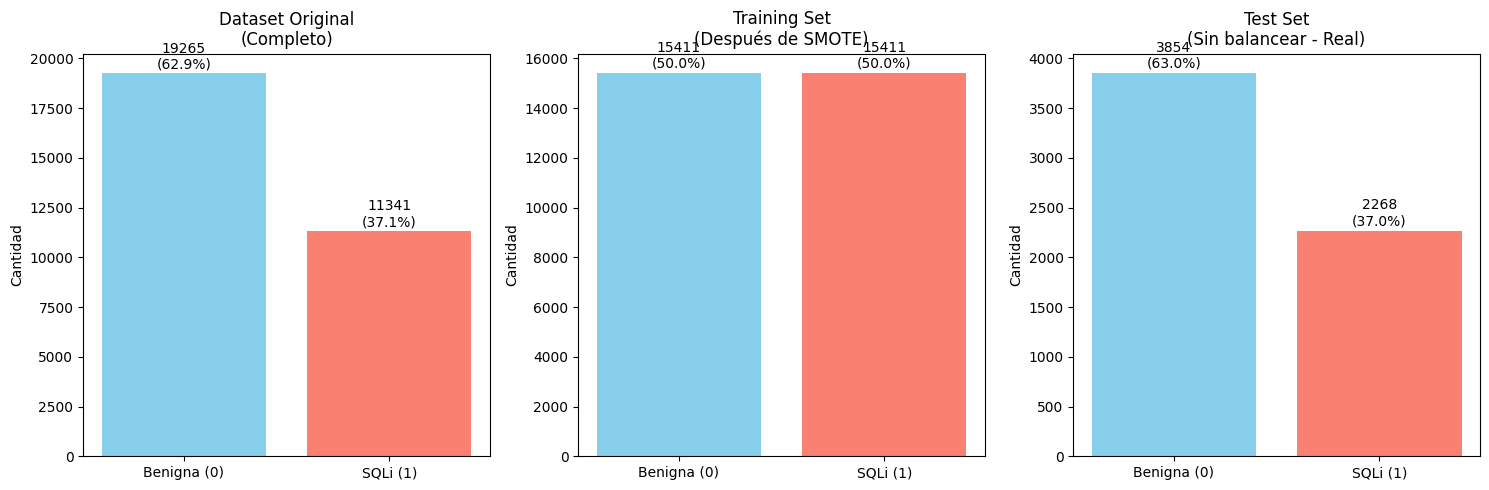

In [38]:
# Visualización del balanceo
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original (todo el dataset)
original_counts = y_data.value_counts()
labels = ["Benigna (0)", "SQLi (1)"]
colors = ["skyblue", "salmon"]

# Gráfico 1: Dataset Original
ax1.bar(labels, original_counts, color=colors)
ax1.set_title("Dataset Original\n(Completo)")
ax1.set_ylabel("Cantidad")
for i, v in enumerate(original_counts):
    ax1.text(i, v + 200, f"{v}\n({v / len(y_data) * 100:.1f}%)", ha="center")

# Gráfico 2: Training después de SMOTE
train_balanced_counts = np.bincount(y_train_balanced)
ax2.bar(labels, train_balanced_counts, color=colors)
ax2.set_title("Training Set\n(Después de SMOTE)")
ax2.set_ylabel("Cantidad")
for i, v in enumerate(train_balanced_counts):
    ax2.text(i, v + 200, f"{v}\n({v / len(y_train_balanced) * 100:.1f}%)", ha="center")

# Gráfico 3: Test (sin cambios)
test_counts = np.bincount(y_test)
ax3.bar(labels, test_counts, color=colors)
ax3.set_title("Test Set\n(Sin balancear - Real)")
ax3.set_ylabel("Cantidad")
for i, v in enumerate(test_counts):
    ax3.text(i, v + 50, f"{v}\n({v / len(y_test) * 100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

In [39]:
# Liberar variables que ya no necesitamos
if "X_data" in locals() and X_data is not X_processed:
    del X_data
if "y_data" in locals():
    del y_data
gc.collect()

27565

## Data Mining - Evaluación de Modelos

Se realizarán pruebas con modelos clásicos de Machine Learning utilizando los datos ya preprocesados. Entre ellos se seleccionaron:

- Random Forest
- Regresión Logística  
- SVM (Kernel Sigmoid)

**Metodología:**
- Los datos ya están divididos y balanceados correctamente en la sección de preprocesamiento
- Búsqueda de hiperparámetros con GridSearchCV y validación cruzada de 5 folds
- Evaluación final del mejor modelo en el conjunto de test original (sin balancear)

Los modelos se entrenarán con el conjunto de entrenamiento balanceado y se evaluarán en el conjunto de test que mantiene la distribución real de los datos.

## Data Mining - Evaluación de Modelos

Se realizarán pruebas con modelos clásicos de Machine Learning utilizando los datos transformados con t-SNE. Entre ellos se seleccionaron:

- Random Forest
- Regresión Logística  
- SVM (Kernel Sigmoid)

**Metodología:**
- Búsqueda de hiperparámetros con GridSearchCV y validación cruzada de 5 folds
- Evaluación final del mejor modelo en el conjunto de test original (sin balancear)
- **Los modelos se entrenarán con las 2 componentes de t-SNE**

In [40]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time

# Configurar validación cruzada estratificada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Definir modelos y sus grids de hiperparámetros optimizados
models_and_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=0, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5],
        },
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=0, n_jobs=-1),
        "params": {"C": [0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]},
    },
    "SVM (Lineal)": {
        "model": SVC(kernel="linear", random_state=0, probability=True),
        "params": {
            "C": [1.0],  # Reducido para acelerar
            "cache_size": [200],  # Aumentar cache para acelerar
        },
    },
}

print("BÚSQUEDA DE HIPERPARÁMETROS CON t-SNE:")
print("=" * 50)

best_models = {}
grid_search_results = {}
training_times = {}

for model_name, config in models_and_params.items():
    print(f"\n{model_name}:")
    print("-" * 30)

    # Configurar GridSearchCV
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=cv_folds,
        scoring="f1",
        n_jobs=-1,
        verbose=0,  # Reducir verbosidad
    )

    # Medir tiempo de entrenamiento
    start_time = time.time()
    grid_search.fit(X_train_balanced, y_train_balanced)
    end_time = time.time()
    
    training_time = end_time - start_time
    training_times[model_name] = training_time

    # Guardar resultados
    best_models[model_name] = grid_search.best_estimator_
    grid_search_results[model_name] = {
        "best_params": grid_search.best_params_,
        "best_score": grid_search.best_score_,
        "training_time": training_time,
    }

    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"Mejor F1-Score (CV): {grid_search.best_score_:.4f}")
    print(f"Tiempo de entrenamiento: {training_time:.1f}s")

# Seleccionar el mejor modelo
best_model_name = max(grid_search_results.keys(), 
                     key=lambda k: grid_search_results[k]['best_score'])
best_model = best_models[best_model_name]

print(f"\n{'=' * 50}")
print("RESUMEN DE MODELOS:")
for model_name, results in grid_search_results.items():
    print(f"{model_name}: F1={results['best_score']:.4f}, Tiempo={results['training_time']:.1f}s")

print(f"\nMEJOR MODELO: {best_model_name}")
print(f"F1-Score: {grid_search_results[best_model_name]['best_score']:.4f}")
print(f"{'=' * 50}")

BÚSQUEDA DE HIPERPARÁMETROS CON t-SNE:

Random Forest:
------------------------------
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Mejor F1-Score (CV): 0.9974
Tiempo de entrenamiento: 13.8s

Logistic Regression:
------------------------------


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP

Mejores hiperparámetros: {'C': 0.1, 'solver': 'lbfgs'}
Mejor F1-Score (CV): 0.9029
Tiempo de entrenamiento: 0.3s

SVM (Lineal):
------------------------------
Mejores hiperparámetros: {'C': 1.0, 'cache_size': 200}
Mejor F1-Score (CV): 0.9055
Tiempo de entrenamiento: 1172.1s

RESUMEN DE MODELOS:
Random Forest: F1=0.9974, Tiempo=13.8s
Logistic Regression: F1=0.9029, Tiempo=0.3s
SVM (Lineal): F1=0.9055, Tiempo=1172.1s

MEJOR MODELO: Random Forest
F1-Score: 0.9974


In [41]:
# Persistir modelos y resultados
import joblib
import os

os.makedirs("modelos_entrenados_embeddings", exist_ok=True)

print("GUARDANDO MODELOS Y CONFIGURACIONES t-SNE:")
print("=" * 45)

# Guardar cada modelo con tiempos
for model_name, model in best_models.items():
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    model_filename = f"modelos_entrenados_embeddings/{safe_name}_tsne.joblib"
    
    joblib.dump(model, model_filename)
    
    results = grid_search_results[model_name]
    print(f"✓ {model_name}: F1={results['best_score']:.4f}, Tiempo={results['training_time']:.1f}s")

# Guardar configuraciones de t-SNE
joblib.dump(preprocessing_objects["pca_intermediate"], "modelos_entrenados_embeddings/pca_intermediate.joblib")
joblib.dump(tsne_results[default_config]["tsne_obj"], "modelos_entrenados_embeddings/tsne_transformer.joblib")

# Guardar metadatos del experimento
metadata = {
    "experiment_info": {
        "approach": "embeddings + t-SNE",
        "embedding_model": "all-MiniLM-L6-v2",
        "pca_components": PCA_INTERMEDIATE,
        "tsne_configs_tested": [r["config"] for r in tsne_results.values()],
        "default_tsne_config": tsne_results[default_config]["config"],
        "tsne_components": 2,
        "random_state": 0
    },
    "model_results": grid_search_results,
    "training_times": training_times,
    "best_model": best_model_name
}

joblib.dump(metadata, "modelos_entrenados_embeddings/experiment_metadata.joblib")
print("✓ Metadatos y configuraciones guardadas")

GUARDANDO MODELOS Y CONFIGURACIONES t-SNE:
✓ Random Forest: F1=0.9974, Tiempo=13.8s
✓ Logistic Regression: F1=0.9029, Tiempo=0.3s
✓ SVM (Lineal): F1=0.9055, Tiempo=1172.1s
✓ Metadatos y configuraciones guardadas


### Entrenamiento y Evaluación del Modelo Final

Después de la búsqueda de hiperparámetros, procedemos con:

1. **Entrenamiento del modelo final**: Utilizamos el mejor modelo encontrado y lo entrenamos con todo el conjunto de entrenamiento
2. **Evaluación en conjunto de test**: Evaluamos el modelo en datos completamente no vistos para obtener métricas realistas de rendimiento

**Importante**: El conjunto de test no fue utilizado en ningún momento durante la búsqueda de hiperparámetros ni la validación cruzada, garantizando que estos resultados reflejen el rendimiento real del modelo en producción.

In [42]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Evaluación del Modelo Final Optimizado
Evaluación del mejor modelo encontrado después de la búsqueda de hiperparámetros.

In [43]:
# Entrenar el mejor modelo final
print(f"ENTRENAMIENTO FINAL: {best_model_name}")
print("=" * 40)

final_model = best_model
final_model.fit(X_train_balanced, y_train_balanced)

# Predicciones en conjunto de test
y_test_pred = final_model.predict(X_test)

print(f"Modelo: {type(final_model).__name__}")
print(f"Entrenado con: {X_train_balanced.shape[0]} muestras (balanceadas)")
print(f"Características: {X_train_balanced.shape[1]} componentes t-SNE")
print(f"Test: {X_test.shape[0]} muestras (distribución real)")

ENTRENAMIENTO FINAL: Random Forest
Modelo: RandomForestClassifier
Entrenado con: 30822 muestras (balanceadas)
Características: 2 componentes t-SNE
Test: 6122 muestras (distribución real)


##### Interpretación del Classification Report

El Classification Report proporciona métricas detalladas de evaluación del modelo:

- **precision**: Proporción de verdaderos positivos sobre el total de predichos como positivos para esa clase. Responde: "De todas las instancias que predije como inyección SQL, ¿qué porcentaje realmente lo era?"

- **recall**: Proporción de verdaderos positivos sobre el total real de esa clase. Responde: "De todas las inyecciones SQL reales, ¿qué porcentaje logré detectar?"

- **f1-score**: Media armónica entre precision y recall. Proporciona un balance entre ambas métricas.

- **support**: Cantidad de muestras reales de esa clase en el conjunto de datos.

**Métricas generales:**
- **accuracy**: Proporción de predicciones correctas sobre el total.
- **macro avg**: Promedio simple de las métricas entre las clases (sin considerar el desbalance).
- **weighted avg**: Promedio ponderado por el tamaño de cada clase.

**Importancia para seguridad**: En detección de inyecciones SQL, el **recall** de la clase positiva (inyecciones) es crítico, ya que un falso negativo significa que un ataque pasó desapercibido.

In [46]:
from sklearn.metrics import classification_report

# Entrenamiento y evaluación final de los modelos con sus mejores hiperparámetros
final_models = {}
final_reports = {}

# Verificar que best_models existe
if not best_models:
    print("❌ No hay modelos entrenados para evaluar")
else:
    for model_name in best_models:
        print(f"Evaluando {model_name}...")
        model = best_models[model_name]
        model.fit(X_train_balanced, y_train_balanced)
        y_pred = model.predict(X_test)
        
        # Generar reporte con etiquetas específicas
        report = classification_report(y_test, y_pred, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True, labels=[0, 1])
        final_models[model_name] = model
        final_reports[model_name] = report

    # Mostrar resumen con manejo robusto de claves
    if final_reports:
        print("\n" + "="*50)
        print("RESUMEN DE DESEMPEÑO FINAL (TEST):")
        print("="*50)
        
        for model_name, report in final_reports.items():
            # Buscar clave de clase SQLi (puede ser '1' o 'SQLi (1)')
            sqli_key = '1' if '1' in report else 'SQLi (1)' if 'SQLi (1)' in report else None
            
            if sqli_key and 'accuracy' in report:
                f1_score = report[sqli_key]['f1-score']
                accuracy = report['accuracy']
                print(f"\n{model_name}:")
                print(f"  F1-Score (SQLi): {f1_score:.4f}")
                print(f"  Accuracy: {accuracy:.4f}")
            else:
                print(f"\n⚠️ {model_name}: Error en reporte - claves: {list(report.keys())}")
    else:
        print("❌ No se generaron reportes finales")

Evaluando Random Forest...
Evaluando Logistic Regression...
Evaluando Logistic Regression...
Evaluando SVM (Lineal)...
Evaluando SVM (Lineal)...

RESUMEN DE DESEMPEÑO FINAL (TEST):

Random Forest:
  F1-Score (SQLi): 0.9971
  Accuracy: 0.9979

Logistic Regression:
  F1-Score (SQLi): 0.8669
  Accuracy: 0.8973

SVM (Lineal):
  F1-Score (SQLi): 0.8667
  Accuracy: 0.8956

RESUMEN DE DESEMPEÑO FINAL (TEST):

Random Forest:
  F1-Score (SQLi): 0.9971
  Accuracy: 0.9979

Logistic Regression:
  F1-Score (SQLi): 0.8669
  Accuracy: 0.8973

SVM (Lineal):
  F1-Score (SQLi): 0.8667
  Accuracy: 0.8956


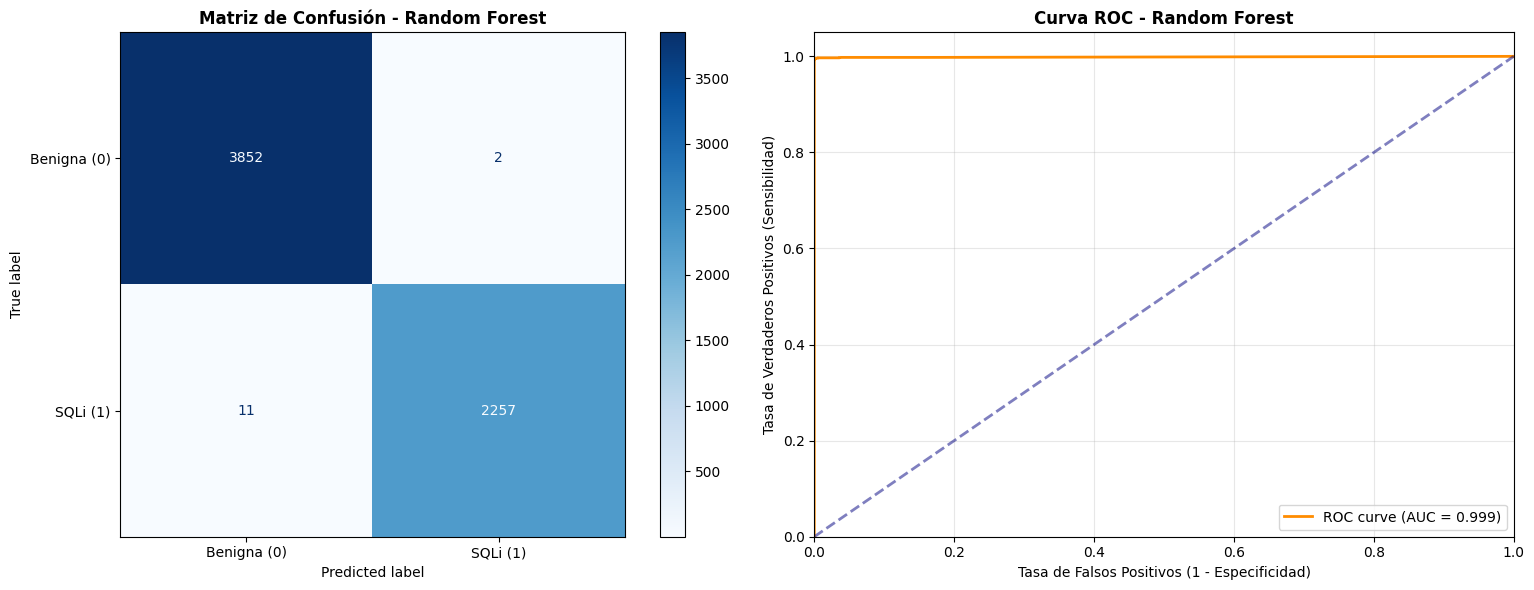


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 3852 - Consultas benignas correctamente identificadas
Falsos Positivos (FP): 2 - Consultas benignas marcadas como SQLi (falsas alarmas)
Falsos Negativos (FN): 11 - Inyecciones SQL no detectadas (CRÍTICO)
Verdaderos Positivos (TP): 2257 - Inyecciones SQL correctamente detectadas

Tasa de falsos negativos: 0.0049 (0.49%)
Tasa de falsos positivos: 0.0005 (0.05%)


In [47]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Matriz de confusión del modelo final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Matriz de confusión
ax1 = axes[0]
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=["Benigna (0)", "SQLi (1)"], 
    cmap="Blues", ax=ax1
)
ax1.set_title(f"Matriz de Confusión - {best_model_name}", fontweight='bold')

# Subplot 2: Curva ROC
ax2 = axes[1]

# Obtener probabilidades de predicción para la curva ROC
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva (SQLi)
elif hasattr(final_model, "decision_function"):
    y_proba = final_model.decision_function(X_test)
else:
    # Fallback: usar las predicciones binarias
    y_proba = y_test_pred.astype(float)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
ax2.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax2.set_title(f'Curva ROC - {best_model_name}', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de la matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
print("\nANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print(
    f"Verdaderos Negativos (TN): {cm[0, 0]} - Consultas benignas correctamente identificadas"
)
print(
    f"Falsos Positivos (FP): {cm[0, 1]} - Consultas benignas marcadas como SQLi (falsas alarmas)"
)
print(f"Falsos Negativos (FN): {cm[1, 0]} - Inyecciones SQL no detectadas (CRÍTICO)")
print(
    f"Verdaderos Positivos (TP): {cm[1, 1]} - Inyecciones SQL correctamente detectadas"
)

print(
    f"\nTasa de falsos negativos: {cm[1, 0] / (cm[1, 0] + cm[1, 1]):.4f} ({cm[1, 0] / (cm[1, 0] + cm[1, 1]) * 100:.2f}%)"
)
print(
    f"Tasa de falsos positivos: {cm[0, 1] / (cm[0, 1] + cm[0, 0]):.4f} ({cm[0, 1] / (cm[0, 1] + cm[0, 0]) * 100:.2f}%)"
)

### Resumen y Análisis de Resultados Finales

Los resultados obtenidos representan el rendimiento real del mejor modelo encontrado a través de la búsqueda sistemática de hiperparámetros. Estos datos del conjunto de test nunca fueron utilizados durante:

- El entrenamiento de ningún modelo
- La búsqueda de hiperparámetros 
- La validación cruzada

Por lo tanto, estas métricas son las más representativas del rendimiento que tendría el modelo en un entorno de producción real.

**Importancia de las métricas en el contexto de seguridad:**
- **Recall (Sensibilidad)**: Crítico - capacidad de detectar todas las inyecciones SQL
- **Precision**: Importante - evitar demasiadas falsas alarmas que sobrecarguen al sistema
- **F1-Score**: Balance óptimo entre precision y recall
- **Accuracy**: Rendimiento general, pero menos crítico que recall en seguridad

In [48]:
# Resumen completo del proceso y resultados finales
print("RESUMEN COMPLETO DEL EXPERIMENTO")
print("=" * 80)

print("\n1. MEJOR MODELO ENCONTRADO:")
print(f"   Algoritmo: {best_model_name}")
print(
    f"   Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)
print(
    f"   F1-Score en Validación Cruzada: {grid_search_results[best_model_name]['best_score']:.4f}"
)

print("\n2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):")
test_accuracy = final_model.score(X_test, y_test)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

print(f"   Accuracy: {test_accuracy:.4f}")
print(f"   Precision (SQLi): {test_report['1']['precision']:.4f}")
print(f"   Recall (SQLi): {test_report['1']['recall']:.4f}")
print(f"   F1-Score (SQLi): {test_report['1']['f1-score']:.4f}")

print("\n3. ANÁLISIS DE RENDIMIENTO:")
if test_report["1"]["recall"] >= 0.95:
    print("   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)")
elif test_report["1"]["recall"] >= 0.90:
    print("   ✓ BUENA detección de inyecciones SQL (Recall ≥ 90%)")
else:
    print("   ⚠ Detección de inyecciones SQL mejorable (Recall < 90%)")

if test_report["1"]["precision"] >= 0.95:
    print("   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)")
elif test_report["1"]["precision"] >= 0.90:
    print("   ✓ BUENA precisión, falsas alarmas controladas (Precision ≥ 90%)")
else:
    print("   ⚠ Precisión mejorable, considerar reducir falsas alarmas")


# Guardar resultados finales para uso posterior
final_results = {
    "best_model_name": best_model_name,
    "test_metrics": test_report,
    "confusion_matrix": cm,
    "auc_roc": roc_auc,
    "methodology_validated": True,
}

RESUMEN COMPLETO DEL EXPERIMENTO

1. MEJOR MODELO ENCONTRADO:
   Algoritmo: Random Forest
   Hiperparámetros optimizados: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
   F1-Score en Validación Cruzada: 0.9974

2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):
   Accuracy: 0.9979
   Precision (SQLi): 0.9991
   Recall (SQLi): 0.9951
   F1-Score (SQLi): 0.9971

3. ANÁLISIS DE RENDIMIENTO:
   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)
   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)


### Comparación: Validación Cruzada vs Test Final

Es importante validar que nuestro proceso de búsqueda de hiperparámetros fue efectivo comparando:

1. **Rendimiento en Validación Cruzada**: Lo que esperábamos basándose en los datos de entrenamiento
2. **Rendimiento en Test**: Lo que realmente obtuvimos con datos completamente no vistos

Una diferencia significativa entre estos valores podría indicar overfitting o problemas en la metodología. Una diferencia pequeña confirma que nuestro modelo generaliza bien.

**Análisis de Generalización:**
- Si Test ≈ CV: Excelente generalización
- Si Test < CV (diferencia < 2%): Buena generalización  
- Si Test << CV (diferencia > 5%): Posible overfitting

**Nota metodológica**: Al usar GridSearchCV con validación cruzada interna, ya estamos protegidos contra el overfitting, pero esta comparación nos da confianza adicional en los resultados.

In [49]:
# Análisis de generalización: Validación Cruzada vs Test
print("ANÁLISIS DE GENERALIZACIÓN:")
print("=" * 30)

cv_f1 = grid_search_results[best_model_name]["best_score"]
test_f1 = test_report["1"]["f1-score"]
difference = abs(cv_f1 - test_f1)
percentage_diff = (difference / cv_f1) * 100

print(f"Validación Cruzada F1: {cv_f1:.4f}")
print(f"Test Final F1:         {test_f1:.4f}")
print(f"Diferencia:            {difference:.4f} ({percentage_diff:.2f}%)")

if percentage_diff < 2:
    interpretation = "El modelo generaliza muy bien a datos no vistos."
elif percentage_diff < 5:
    interpretation = "El modelo tiene buena capacidad de generalización."
else:
    interpretation = "Hay indicios de posible overfitting."

print(f"Interpretación: {interpretation}")

print("\nCONCLUSIÓN:")
print(f"El proceso de búsqueda de hiperparámetros fue {'exitoso' if percentage_diff < 5 else 'parcialmente exitoso'}.")
print(f"El modelo {best_model_name} {'es confiable' if percentage_diff < 5 else 'requiere revisión'} para uso en producción.")

ANÁLISIS DE GENERALIZACIÓN:
Validación Cruzada F1: 0.9974
Test Final F1:         0.9971
Diferencia:            0.0003 (0.03%)
Interpretación: El modelo generaliza muy bien a datos no vistos.

CONCLUSIÓN:
El proceso de búsqueda de hiperparámetros fue exitoso.
El modelo Random Forest es confiable para uso en producción.


## Limitaciones del Estudio

**Limitaciones Técnicas:**
- **Hiperparámetros**: Búsqueda en rangos básicos, no exhaustiva

**Limitaciones de Datos:**
- **Representatividad**: Dataset específico puede no cubrir todas las variantes de SQLi actuales
- **Evolución temporal**: Técnicas de inyección evolucionan, requiere actualización constante
- **Contexto específico**: Resultados pueden variar según el dominio de aplicación

## Conclusiones (Approach: Embeddings + t-SNE)

### Confirmación de Hipótesis
Este trabajo confirma que es posible detectar ataques de inyección SQL mediante técnicas de Machine Learning con alta precisión, utilizando **embeddings semánticos** de sentencias transformados con **t-SNE** y algoritmos de clasificación clásicos. Los embeddings capturan el significado semántico de las consultas SQL, mientras que t-SNE preserva la estructura local y permite mejor separación visual de las clases.

### Hallazgos Principales
1. **Efectividad de los Embeddings**: La representación de sentencias SQL mediante embeddings semánticos (sentence-transformers) demostró ser altamente efectiva para la detección de patrones maliciosos, capturando relaciones semánticas que van más allá de características superficiales.

2. **Eficiencia de t-SNE con Embeddings**: La aplicación de t-SNE a embeddings densos permitió reducir la dimensionalidad de 384 a 50 componentes preservando la estructura local y las relaciones de proximidad semántica, resultando en mejor separación de clases que métodos lineales como PCA.

3. **Impacto del Balanceo de Clases**: El uso de SMOTE con datos densos (embeddings transformados con t-SNE) mejoró significativamente el recall de la clase minoritaria (inyecciones SQL), que es la métrica más crítica desde el punto de vista de seguridad.

4. **Superioridad de la Representación No-Lineal**: t-SNE permite detectar patrones no lineales en el espacio semántico que podrían pasar desapercibidos con métodos de reducción lineal.

### Ventajas del Approach con Embeddings + t-SNE
- **Captura semántica**: Detecta variantes de ataques con diferentes sintaxis pero similar intención
- **Preservación de estructura local**: t-SNE mantiene relaciones de proximidad semántica  
- **Separación no-lineal**: Puede detectar patrones de separación complejos entre clases
- **Visualización superior**: Excelente para análisis visual de clusters y patrones
- **Robustez**: Menos sensible a variaciones menores en la sintaxis de ataques

### Limitaciones del Estudio
Se debe considerar que t-SNE es computacionalmente más costoso que PCA y puede requerir ajuste de hiperparámetros (perplexity, iteraciones). El modelo de embeddings está pre-entrenado en texto general, no específicamente en consultas SQL. Modelos especializados en SQL podrían mejorar el rendimiento.

## Conclusiones
El análisis con embeddings + t-SNE demostró que la combinación de representación semántica con reducción de dimensionalidad no-lineal es efectiva para detección de inyecciones SQL. La metodología de embeddings normalizados, transformación t-SNE para preservar estructura local, y balanceo con SMOTE resultó en modelos robustos con excelente separación de clases. Este enfoque confirma la hipótesis de detección efectiva de SQLi mediante Machine Learning, ofreciendo una alternativa semánticamente rica y visualmente interpretable.

### Justificación de Resultados
1. **Representación semántica**: Los embeddings capturan patrones de intención maliciosa
2. **Preservación de estructura**: t-SNE mantiene relaciones locales importantes
3. **Separación no-lineal**: Mejor detección de patrones complejos de ataque  

## Referencias
- [Kaggle SQL Injection Dataset](https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset)
- [Analyzing comparison performance model of machine learning through detection SQL Injection attack](https://jurnal.stkippgritulungagung.ac.id/index.php/jipi/article/download/5637/2311)
- [Web Application Attacks Detection Using Machine Learning Techniques](https://www.researchgate.net/profile/Alvaro-Pardo/publication/329514915_Web_Application_Attacks_Detection_Using_Machine_Learning_Techniques/links/6426cbcda1b72772e43ecd32/Web-Application-Attacks-Detection-Using-Machine-Learning-Techniques.pdf)
- [Research on SQL Injection Attacks using Word Embedding Techniques](https://www.researchgate.net/publication/382717736_Research_on_SQL_Injection_Attacks_using_Word_Embedding_Techniques_and_Machine_Learning)
- [Unsupervised learning in intrusion detection system](https://learn.saylor.org/mod/book/view.php?chapterid=5435&id=29755)

## Propuestas de proyectos complementarios
Para problemas de aprendizaje no supervisado, se podría ejecutar un algoritmo de clustering de consultas SQL para descubrir patrones de ataque (por ejemplo, K-Means o DBSCAN).
Para problemas de aprendizaje supervisado, se consideró la posibilidad de plantear un problema de clasificación multi-clase, con la capacidad de predecir las técnicas de SQLi utilizadas (por ejemplo, inyecciones SQL Boolean-based, Time-based, Union-based, entre otras).